# Machine Learning Fundamentals  
## Practical Notebook with Cane Corso Example

В този notebook показвам основните идеи от лекцията по **Machine Learning Fundamentals**, но чрез собствен практически пример.

Темата на примера е:

**Predicting approximate Cane Corso weight from age, height, activity level and sex.**

Важно:  
Данните са **синтетични** и се използват само за учебна демонстрация.  
Това не е ветеринарна оценка и не трябва да се използва за реална медицинска преценка.


## Lecture Topics Covered

Този notebook следва логиката на лекцията:

1. Machine Learning Basics  
2. Objective Function, Cost Function and Optimization  
3. Linear Regression  
4. Training and Testing  
5. Model Performance Evaluation  
6. Regression with Outliers and RANSAC  
7. Polynomial Regression  
8. Bias–Variance Tradeoff  
9. Regularization  
10. Learning and Validation Curves  
11. Cross-Validation  
12. Hyperparameter Tuning  
13. Model Selection  
14. Feature Selection and Feature Engineering


# 1. Machine Learning Basics

Machine Learning означава моделът да се учи от данни.

В този пример имам:
- **features / input variables** — възраст, височина, активност, пол;
- **target / output variable** — тегло;
- **model** — алгоритъм, който намира зависимост;
- **prediction** — приблизително предсказано тегло.

Това е **supervised learning**, защото моделът вижда примери с входни данни и правилен отговор.


## 1.1 Import Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    learning_curve,
    validation_curve
)

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    RANSACRegressor
)

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [3]:
np.random.seed(42)


# 2. Dataset Creation

Тъй като нямаме реална база с измервания, създавам синтетичен dataset.

Колони:
- `age_months` — възраст в месеци;
- `height_cm` — височина;
- `activity_level` — активност от 1 до 5;
- `sex_male` — 1 за мъжки, 0 за женски;
- `weight_kg` — тегло в килограми.

Идеята е да имам реалистично изглеждащи учебни данни, с които да покажа ML процеса.


## 2.1 Generate Base Features


In [4]:
n = 220

age_months = np.random.randint(3, 84, n)
sex_male = np.random.binomial(1, 0.55, n)
activity_level = np.random.randint(1, 6, n)


## 2.2 Generate Synthetic Height

Тук създавам примерна височина.  
Използвам възрастта, пола и малко случайност, за да не изглеждат данните прекалено идеални.


In [5]:
height_cm = (
    38
    + 0.58 * age_months
    - 0.0038 * age_months**2
    + sex_male * 4.2
    + np.random.normal(0, 3.2, n)
)

height_cm = np.clip(height_cm, 38, 72)


## 2.3 Generate Synthetic Weight

Теглото зависи от:
- възраст;
- височина;
- пол;
- активност;
- случайна разлика между отделните Cane Corso профили.


In [6]:
weight_kg = (
    5.5
    + 0.62 * age_months
    - 0.0045 * age_months**2
    + 0.70 * height_cm
    + sex_male * 5.0
    + activity_level * 0.75
    + np.random.normal(0, 4.2, n)
)

weight_kg = np.clip(weight_kg, 8, 72)


## 2.4 Create DataFrame


In [7]:
df = pd.DataFrame({
    "age_months": age_months,
    "height_cm": height_cm.round(1),
    "activity_level": activity_level,
    "sex_male": sex_male,
    "weight_kg": weight_kg.round(1)
})

df.head()


,age_months,height_cm,activity_level,sex_male,weight_kg
0,54,56.9,5,0,64.7
1,17,49.9,1,1,54.8
2,74,58.8,3,1,72.0
3,63,68.3,1,1,72.0
4,23,52.2,1,0,58.0


In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age_months      220 non-null    int32  
 1   height_cm       220 non-null    float64
 2   activity_level  220 non-null    int32  
 3   sex_male        220 non-null    int32  
 4   weight_kg       220 non-null    float64
dtypes: float64(2), int32(3)
memory usage: 6.1 KB


In [9]:
df.describe().round(2)


,age_months,height_cm,activity_level,sex_male,weight_kg
count,220.00,220.00,220.00,220.00,220.00
mean,42.53,55.64,3.08,0.51,62.71
std,24.28,8.01,1.51,0.50,10.71
min,3.00,38.00,1.00,0.00,31.50
25%,21.00,50.75,2.00,0.00,58.15
50%,44.00,57.30,3.00,1.00,66.30
75%,64.00,61.60,5.00,1.00,72.00
max,83.00,70.20,5.00,1.00,72.00


# 3. Data Exploration

Преди да обуча модел, разглеждам данните.

Това е важна част от ML процеса, защото моделът не трябва да се пуска „на сляпо“.


## 3.1 Age vs Weight


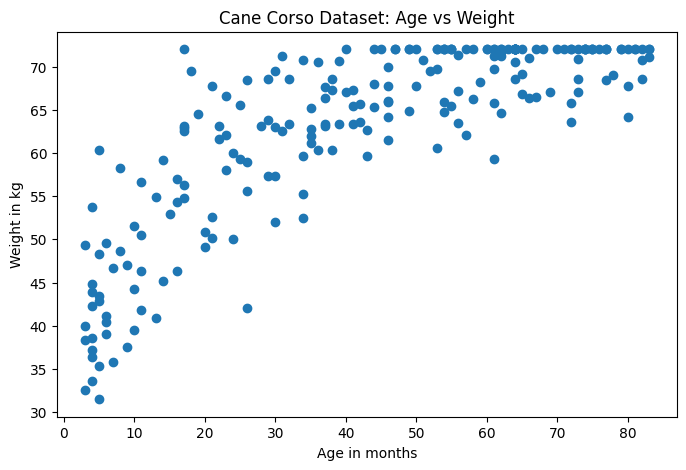

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(df["age_months"], df["weight_kg"])
plt.xlabel("Age in months")
plt.ylabel("Weight in kg")
plt.title("Cane Corso Dataset: Age vs Weight")
plt.show()


## 3.2 Height vs Weight


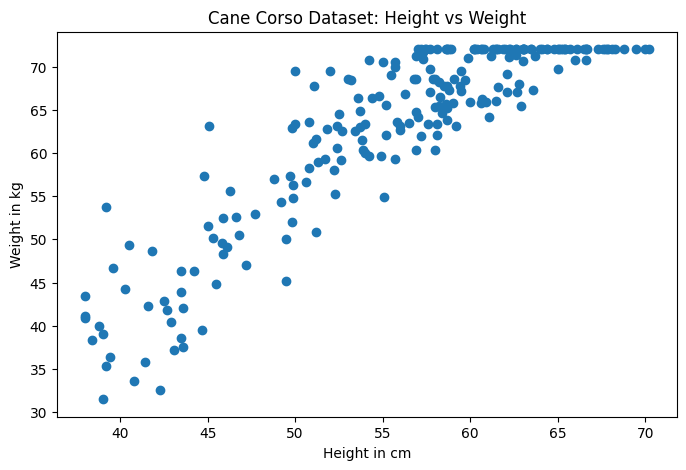

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(df["height_cm"], df["weight_kg"])
plt.xlabel("Height in cm")
plt.ylabel("Weight in kg")
plt.title("Cane Corso Dataset: Height vs Weight")
plt.show()


## 3.3 Correlation Matrix

Корелацията показва кои променливи имат по-силна връзка с теглото.


In [12]:
df.corr(numeric_only=True).round(3)


,age_months,height_cm,activity_level,sex_male,weight_kg
age_months,1.000,0.831,-0.064,-0.085,0.807
height_cm,0.831,1.000,-0.091,0.236,0.893
activity_level,-0.064,-0.091,1.000,0.005,-0.037
sex_male,-0.085,0.236,0.005,1.000,0.221
weight_kg,0.807,0.893,-0.037,0.221,1.000


# 4. Objective Function, Cost Function and Optimization

Целта на модела е да направи възможно най-малка грешка.

За regression често използваме грешки като:
- **MAE** — средна абсолютна грешка;
- **MSE** — средна квадратична грешка;
- **R²** — колко добре моделът обяснява вариацията в данните.

При обучението моделът търси параметри, които минимизират cost function.


# 5. Linear Regression

Linear Regression търси линейна зависимост.

Формата е приблизително:

`predicted_weight = a1 * age + a2 * height + a3 * activity + a4 * sex + b`

Коефициентите се намират от модела по време на обучението.


## 5.1 Prepare Features and Target


In [13]:
features = ["age_months", "height_cm", "activity_level", "sex_male"]
target = "weight_kg"

X = df[features]
y = df[target]


In [14]:
X.head()


,age_months,height_cm,activity_level,sex_male
0,54,56.9,5,0
1,17,49.9,1,1
2,74,58.8,3,1
3,63,68.3,1,1
4,23,52.2,1,0


In [15]:
y.head()


0    64.7
1    54.8
2    72.0
3    72.0
4    58.0
Name: weight_kg, dtype: float64

# 6. Training and Testing

Едно от най-важните правила:

**Не тестваме модела върху същите данни, с които го обучаваме.**

Затова разделям данните на:
- training set;
- test set.


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))


Training rows: 154
Test rows: 66


## 6.1 Train Linear Regression Model


In [17]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 6.2 Model Parameters


In [18]:
print("Intercept:", round(linear_model.intercept_, 3))

for name, coef in zip(features, linear_model.coef_):
    print(name, "=>", round(coef, 3))


Intercept: 7.691
age_months => 0.141
height_cm => 0.838
activity_level => 0.269
sex_male => 2.896


## 6.3 Make Predictions


In [19]:
linear_predictions = linear_model.predict(X_test)
linear_predictions[:10]


array([68.48815172, 65.83505349, 71.8350469 , 69.98089369, 62.89274197,
       76.73767883, 72.55525223, 73.09800423, 78.11463865, 67.96328695])

In [20]:
comparison = pd.DataFrame({
    "real_weight": y_test.values,
    "predicted_weight": linear_predictions.round(1),
    "error": (y_test.values - linear_predictions).round(1)
})

comparison.head(10)


,real_weight,predicted_weight,error
0,72.0,68.5,3.5
1,65.9,65.8,0.1
2,71.1,71.8,-0.7
3,71.2,70.0,1.2
4,66.3,62.9,3.4
5,72.0,76.7,-4.7
6,72.0,72.6,-0.6
7,72.0,73.1,-1.1
8,72.0,78.1,-6.1
9,72.0,68.0,4.0


# 7. Evaluating Model Performance

След обучението трябва да оценя модела.

Използвам:
- `R² score`
- `MAE`
- `MSE`

Това ми казва дали моделът се представя добре върху нови данни.


In [21]:
def evaluate_regression_model(model_name, y_true, y_pred):
    return {
        "model": model_name,
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred)
    }


In [22]:
linear_metrics = evaluate_regression_model(
    "Linear Regression",
    y_test,
    linear_predictions
)

pd.DataFrame([linear_metrics]).round(3)


,model,R2,MAE,MSE
0,Linear Regression,0.715,3.34,17.216


## 7.1 Residual Plot

Residual = реална стойност - предсказана стойност.

Ако residuals са случайно около 0, моделът изглежда стабилен.  
Ако има ясна форма, моделът не обяснява добре данните.


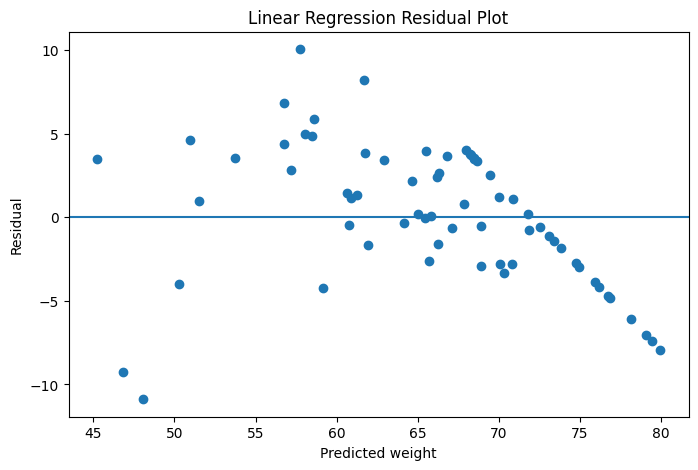

In [23]:
linear_residuals = y_test - linear_predictions

plt.figure(figsize=(8, 5))
plt.scatter(linear_predictions, linear_residuals)
plt.axhline(0)
plt.xlabel("Predicted weight")
plt.ylabel("Residual")
plt.title("Linear Regression Residual Plot")
plt.show()


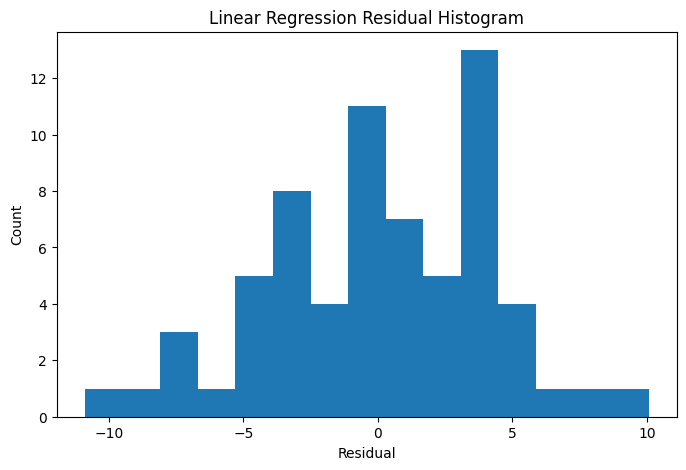

In [24]:
plt.figure(figsize=(8, 5))
plt.hist(linear_residuals, bins=15)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Linear Regression Residual Histogram")
plt.show()


# 8. Polynomial Regression

Понякога линейната зависимост не е достатъчна.

При растежа на Cane Corso теглото може да се променя нелинейно.  
Затова пробвам **Polynomial Regression**.


## 8.1 Train Polynomial Model


In [25]:
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

poly_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [26]:
poly_predictions = poly_model.predict(X_test)

poly_metrics = evaluate_regression_model(
    "Polynomial Regression degree=2",
    y_test,
    poly_predictions
)

pd.DataFrame([linear_metrics, poly_metrics]).round(3)


,model,R2,MAE,MSE
0,Linear Regression,0.715,3.340,17.216
1,Polynomial Regression degree=2,0.833,2.501,10.106


# 9. Bias–Variance Tradeoff

Тук сравнявам различна сложност на polynomial model.

- Ниска сложност може да доведе до **underfitting**.
- Много висока сложност може да доведе до **overfitting**.
- Търсим баланс.


In [27]:
degrees = [1, 2, 3, 5, 8]
degree_results = []

for degree in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    degree_results.append({
        "degree": degree,
        "train_R2": r2_score(y_train, train_pred),
        "test_R2": r2_score(y_test, test_pred),
        "test_MAE": mean_absolute_error(y_test, test_pred)
    })

degree_results_df = pd.DataFrame(degree_results)
degree_results_df.round(3)


,degree,train_R2,test_R2,test_MAE
0,1,0.830,0.716,3.333
1,2,0.896,0.825,2.498
2,3,0.909,0.857,2.224
3,5,0.918,0.858,2.296
4,8,0.924,0.863,2.191


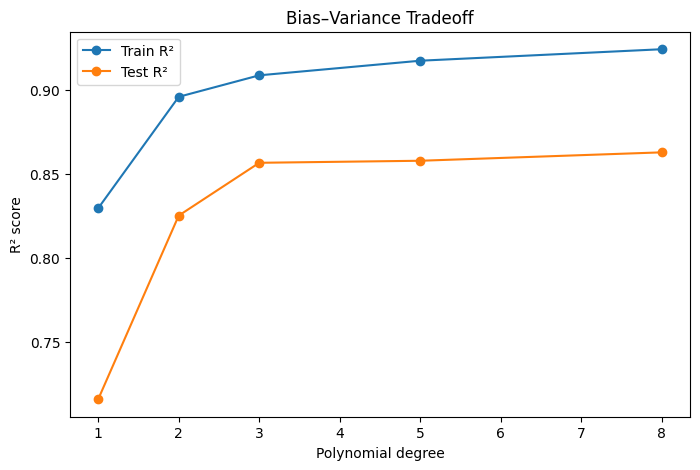

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(degree_results_df["degree"], degree_results_df["train_R2"], marker="o", label="Train R²")
plt.plot(degree_results_df["degree"], degree_results_df["test_R2"], marker="o", label="Test R²")
plt.xlabel("Polynomial degree")
plt.ylabel("R² score")
plt.title("Bias–Variance Tradeoff")
plt.legend()
plt.show()


# 10. Regularization

Regularization помага моделът да не стане прекалено сложен.

В лекцията се разглеждат:
- **Ridge / L2**
- **Lasso / L1**
- **ElasticNet**


In [29]:
regularized_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.05, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=10000)
}


In [30]:
regularization_results = []

for name, model in regularized_models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    regularization_results.append(
        evaluate_regression_model(name, y_test, preds)
    )

regularization_df = pd.DataFrame(regularization_results)
regularization_df.round(3)


,model,R2,MAE,MSE
0,Linear Regression,0.715,3.340,17.216
1,Ridge,0.716,3.333,17.163
2,Lasso,0.719,3.312,17.001
3,ElasticNet,0.720,3.296,16.916


# 11. Regression with Outliers and RANSAC

Outliers са точки, които са много далеч от останалите.

В реални данни това може да е:
- грешно въведено тегло;
- грешна мерна единица;
- необичаен случай;
- неправилно измерване.

RANSAC се опитва да обучи модел, който е по-устойчив на такива точки.


## 11.1 Add Artificial Outliers


In [31]:
df_outliers = df.copy()

outlier_rows = df_outliers.sample(10, random_state=7).index
df_outliers.loc[outlier_rows, "weight_kg"] += np.random.randint(18, 32, len(outlier_rows))

df_outliers.loc[outlier_rows]


,age_months,height_cm,activity_level,sex_male,weight_kg
139,30,59.5,3,1,87.5
65,20,51.2,4,1,69.8
95,37,54.0,1,0,88.3
22,51,54.2,2,0,100.7
63,56,56.5,5,0,94.5
46,55,70.2,1,1,102.0
97,35,58.7,1,1,85.2
11,4,45.5,1,1,71.8
2,74,58.8,3,1,92.0
82,43,56.0,2,0,87.6


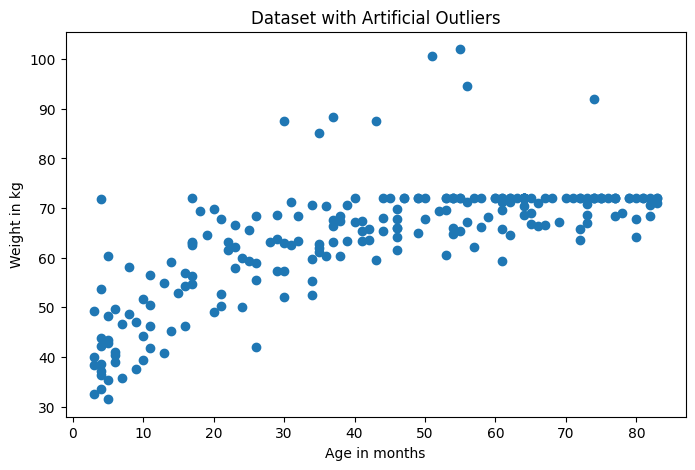

In [32]:
plt.figure(figsize=(8, 5))
plt.scatter(df_outliers["age_months"], df_outliers["weight_kg"])
plt.xlabel("Age in months")
plt.ylabel("Weight in kg")
plt.title("Dataset with Artificial Outliers")
plt.show()


## 11.2 Compare Linear Regression and RANSAC


In [33]:
X_out = df_outliers[features]
y_out = df_outliers[target]

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_out,
    y_out,
    test_size=0.30,
    random_state=42
)


In [34]:
normal_lr = LinearRegression()
normal_lr.fit(X_train_o, y_train_o)
normal_preds = normal_lr.predict(X_test_o)


In [35]:
ransac = RANSACRegressor(
    estimator=LinearRegression(),
    random_state=42,
    min_samples=0.6,
    residual_threshold=8
)

ransac.fit(X_train_o, y_train_o)
ransac_preds = ransac.predict(X_test_o)


In [36]:
outlier_comparison = pd.DataFrame([
    evaluate_regression_model("Linear Regression with outliers", y_test_o, normal_preds),
    evaluate_regression_model("RANSAC with outliers", y_test_o, ransac_preds)
])

outlier_comparison.round(3)


,model,R2,MAE,MSE
0,Linear Regression with outliers,0.382,4.88,53.048
1,RANSAC with outliers,0.381,4.67,53.091


# 12. Cross-Validation

Един train/test split може да е случаен.

Cross-validation разделя данните на няколко части и оценява модела няколко пъти.  
Така получавам по-надеждна оценка.


In [37]:
cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

cv_scores = cross_val_score(
    cv_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross-validation R² scores:", np.round(cv_scores, 3))
print("Average R²:", round(cv_scores.mean(), 3))
print("Standard deviation:", round(cv_scores.std(), 3))


Cross-validation R² scores: [0.87  0.733 0.834 0.768 0.793]
Average R²: 0.8
Standard deviation: 0.048


# 13. Learning Curves

Learning curve показва как се променя резултатът при различен размер на training data.

Ако training и validation резултатите са ниски — може да има high bias.  
Ако има голяма разлика между тях — може да има high variance.


In [38]:
learning_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

train_sizes, train_scores, validation_scores = learning_curve(
    learning_model,
    X,
    y,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.2, 1.0, 5)
)


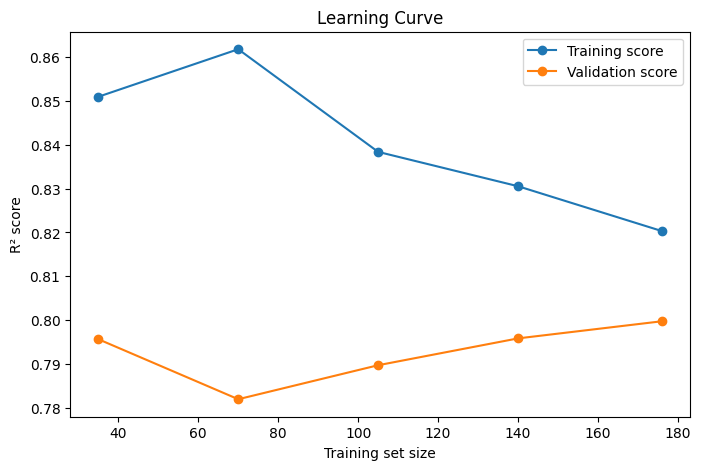

In [39]:
train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Training score")
plt.plot(train_sizes, validation_mean, marker="o", label="Validation score")
plt.xlabel("Training set size")
plt.ylabel("R² score")
plt.title("Learning Curve")
plt.legend()
plt.show()


# 14. Validation Curve

Validation curve показва как параметър на модела влияе върху резултата.

Тук гледам параметъра `alpha` при Ridge regression.


In [40]:
alpha_range = np.array([0.001, 0.01, 0.1, 1, 10, 100])

validation_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

train_scores_alpha, validation_scores_alpha = validation_curve(
    validation_model,
    X,
    y,
    param_name="model__alpha",
    param_range=alpha_range,
    cv=5,
    scoring="r2"
)


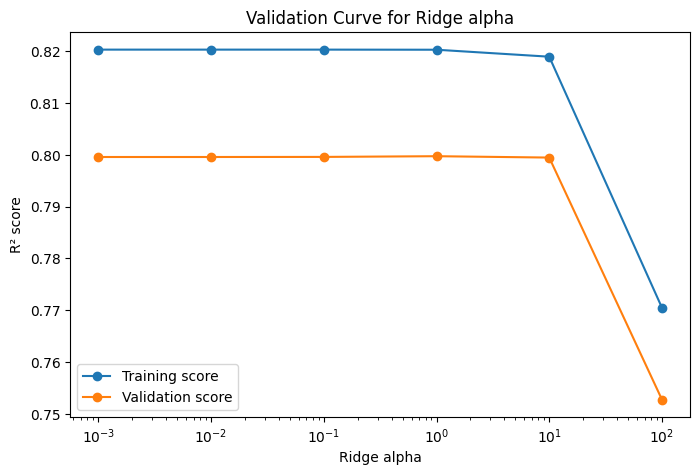

In [41]:
plt.figure(figsize=(8, 5))
plt.semilogx(alpha_range, train_scores_alpha.mean(axis=1), marker="o", label="Training score")
plt.semilogx(alpha_range, validation_scores_alpha.mean(axis=1), marker="o", label="Validation score")
plt.xlabel("Ridge alpha")
plt.ylabel("R² score")
plt.title("Validation Curve for Ridge alpha")
plt.legend()
plt.show()


# 15. Hyperparameter Tuning with Grid Search

Hyperparameters са настройки, които избираме преди обучението.

Grid Search пробва всички зададени комбинации и избира най-добрата.


In [42]:
grid_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}


In [43]:
grid_search = GridSearchCV(
    grid_model,
    param_grid,
    cv=5,
    scoring="r2"
)

grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and cand

In [44]:
best_grid_model = grid_search.best_estimator_
grid_predictions = best_grid_model.predict(X_test)

print("Best alpha:", grid_search.best_params_["model__alpha"])
print("Best CV R²:", round(grid_search.best_score_, 3))
print("Final test R²:", round(r2_score(y_test, grid_predictions), 3))
print("Final test MAE:", round(mean_absolute_error(y_test, grid_predictions), 3), "kg")


Best alpha: 10
Best CV R²: 0.798
Final test R²: 0.723
Final test MAE: 3.258 kg


# 16. Hyperparameter Tuning with Randomized Search

Randomized Search не пробва всички комбинации.  
Той избира случайни варианти от зададен диапазон.

Това може да бъде по-бързо при много параметри.


In [45]:
random_search = RandomizedSearchCV(
    grid_model,
    param_distributions={
        "model__alpha": np.logspace(-3, 2, 50)
    },
    n_iter=10,
    cv=5,
    scoring="r2",
    random_state=42
)

random_search.fit(X_train, y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.",{'model__alpha': array([1.0000...00000000e+02])}
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",

In [46]:
best_random_model = random_search.best_estimator_
random_predictions = best_random_model.predict(X_test)

print("Best randomized alpha:", random_search.best_params_["model__alpha"])
print("Best randomized CV R²:", round(random_search.best_score_, 3))
print("Final test R²:", round(r2_score(y_test, random_predictions), 3))
print("Final test MAE:", round(mean_absolute_error(y_test, random_predictions), 3), "kg")


Best randomized alpha: 9.540954763499943
Best randomized CV R²: 0.798
Final test R²: 0.723
Final test MAE: 3.262 kg


# 17. Model Selection

Сега сравнявам няколко модела и избирам този, който се представя най-добре.

Важно:  
Не гледам само един metric. Гледам цялостната картина.


In [47]:
model_selection_results = [
    linear_metrics,
    poly_metrics,
    evaluate_regression_model("Best GridSearch Ridge", y_test, grid_predictions),
    evaluate_regression_model("Best RandomizedSearch Ridge", y_test, random_predictions)
]

model_selection_df = pd.DataFrame(model_selection_results)
model_selection_df.round(3).sort_values(by="MAE")


,model,R2,MAE,MSE
1,Polynomial Regression degree=2,0.833,2.501,10.106
2,Best GridSearch Ridge,0.723,3.258,16.719
3,Best RandomizedSearch Ridge,0.723,3.262,16.740
0,Linear Regression,0.715,3.340,17.216


# 18. Feature Selection

Feature selection означава да оставим само полезните features.

Lasso може да помогне, защото понякога намалява някои коефициенти почти до 0.


In [48]:
lasso_feature_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.05, max_iter=10000))
])

lasso_feature_model.fit(X_train, y_train)

lasso_coefficients = lasso_feature_model.named_steps["model"].coef_

feature_importance = pd.DataFrame({
    "feature": features,
    "lasso_coefficient": lasso_coefficients
})

feature_importance.round(3)


,feature,lasso_coefficient
0,age_months,3.433
1,height_cm,7.096
2,activity_level,0.342
3,sex_male,1.377


# 19. Feature Engineering

Feature engineering означава да създадем нови features от наличните данни.

Ще добавя:
- `is_adult` — дали Cane Corso е на поне 18 месеца;
- `height_age_ratio` — съотношение височина / възраст;
- `age_squared` — възраст на квадрат.


In [49]:
df_fe = df.copy()

df_fe["is_adult"] = (df_fe["age_months"] >= 18).astype(int)
df_fe["height_age_ratio"] = df_fe["height_cm"] / (df_fe["age_months"] + 1)
df_fe["age_squared"] = df_fe["age_months"] ** 2

df_fe.head()


,age_months,height_cm,activity_level,sex_male,weight_kg,is_adult,height_age_ratio,age_squared
0,54,56.9,5,0,64.7,1,1.034545,2916
1,17,49.9,1,1,54.8,0,2.772222,289
2,74,58.8,3,1,72.0,1,0.784000,5476
3,63,68.3,1,1,72.0,1,1.067187,3969
4,23,52.2,1,0,58.0,1,2.175000,529


In [50]:
features_fe = [
    "age_months",
    "age_squared",
    "height_cm",
    "activity_level",
    "sex_male",
    "is_adult",
    "height_age_ratio"
]

X_fe = df_fe[features_fe]
y_fe = df_fe[target]


In [51]:
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe,
    y_fe,
    test_size=0.30,
    random_state=42
)


In [52]:
feature_engineering_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

feature_engineering_model.fit(X_train_fe, y_train_fe)
feature_engineering_predictions = feature_engineering_model.predict(X_test_fe)


In [53]:
feature_engineering_metrics = evaluate_regression_model(
    "Feature Engineering Ridge",
    y_test_fe,
    feature_engineering_predictions
)

pd.DataFrame([
    linear_metrics,
    poly_metrics,
    feature_engineering_metrics
]).round(3)


,model,R2,MAE,MSE
0,Linear Regression,0.715,3.340,17.216
1,Polynomial Regression degree=2,0.833,2.501,10.106
2,Feature Engineering Ridge,0.839,2.624,9.749


# 20. Final Prediction

Накрая подавам нов Cane Corso профил и моделът връща приблизително тегло.

Това показва как би работил моделът върху нови данни.


In [54]:
new_cane_corso = pd.DataFrame([{
    "age_months": 14,
    "age_squared": 14 ** 2,
    "height_cm": 58,
    "activity_level": 4,
    "sex_male": 1,
    "is_adult": 0,
    "height_age_ratio": 58 / (14 + 1)
}])

new_cane_corso


,age_months,age_squared,height_cm,activity_level,sex_male,is_adult,height_age_ratio
0,14,196,58,4,1,0,3.866667


In [55]:
final_prediction = feature_engineering_model.predict(new_cane_corso)[0]

print("Predicted approximate weight:", round(final_prediction, 1), "kg")


Predicted approximate weight: 59.9 kg


# 21. Final Summary

В този notebook приложих основните идеи от лекцията:

- Machine Learning basics;
- supervised learning;
- regression task;
- objective / cost / error;
- train/test split;
- linear regression;
- model evaluation;
- residual analysis;
- polynomial regression;
- bias–variance tradeoff;
- regularization;
- RANSAC for outliers;
- cross-validation;
- learning curves;
- validation curves;
- grid search;
- randomized search;
- model selection;
- feature selection;
- feature engineering.

Финалната идея е:

**Machine Learning не е само да обучим модел.  
Истинският процес е: данни → модел → обучение → оценка → подобрение → финален тест.**
